In [4]:
from openai import OpenAI
from dotenv import load_dotenv
import json

load_dotenv()

True

In [5]:
ROLES = {
    "1": {
        "name": "一般知識專家",
        "description": "回答各個領域的廣泛一般性問題",
        "details": "針對各個領域的一般性問題，請提供正確且容易理解的回答。"
    },
    "2": {
        "name": "生成式AI產品專家",
        "description": "回答有關生成式AI及相關產品與技術的專業問題",
        "details": "針對生成式AI及相關產品、技術的專業問題，請提供最新資訊與深入洞察。"
    },
    "3": {
        "name": "心理諮詢師",
        "description": "為個人煩惱與心理問題提供支持",
        "details": "針對個人煩惱與心理問題，請提供具同理心且支持性的回應，並在可能的情況下給予適當建議。"
    }
}

In [6]:
import operator
from typing import Annotated

from pydantic import BaseModel, Field


class State(BaseModel):
    query: str = Field(..., description="來自使用者的提問")
    current_role: str = Field(
        default="", description="已選定的回覆角色"
    )
    messages: Annotated[list[str], operator.add] = Field(
        default=[], description="回覆歷史紀錄"
    )
    current_judge: bool = Field(
        default=False, description="品質檢查結果"
    )
    judgement_reason: str = Field(
        default="", description="品質檢查的判定理由"
    )

In [7]:

from langchain_openai import ChatOpenAI
from langchain_core.runnables import ConfigurableField

llm = ChatOpenAI(model="gpt-4o", temperature=0.0)
# 為了能在之後修改 max_tokens 的值，先宣告可變更的欄位
llm = llm.configurable_fields(max_tokens=ConfigurableField(id='max_tokens'))

In [8]:
from typing import Any

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def selection_node(state: State) -> dict[str, Any]:
    query = state.query
    role_options = "\n".join([f"{k}. {v['name']}: {v['description']}" for k, v in ROLES.items()])
    prompt = ChatPromptTemplate.from_template(
"""請分析問題，並選擇最合適的回覆角色。

選項:
{role_options}

請僅回傳選項的編號（1、2 或 3）。

問題: {query}
""".strip()
    )
    # 因為只期待回傳選項的編號，因此將 max_tokens 的值設為 1
    chain = prompt | llm.with_config(configurable=dict(max_tokens=1)) | StrOutputParser()
    role_number = chain.invoke({"role_options": role_options, "query": query})

    selected_role = ROLES[role_number.strip()]["name"]
    return {"current_role": selected_role}

In [9]:
def answering_node(state: State) -> dict[str, Any]:
    query = state.query
    role = state.current_role
    role_details = "\n".join([f"- {v['name']}: {v['details']}" for v in ROLES.values()])
    prompt = ChatPromptTemplate.from_template(
"""請以 {role} 的身分進行回答。請根據你的角色，針對以下問題提供適當的回覆。

角色詳細說明:
{role_details}

問題: {query}

回答:""".strip()
    )
    chain = prompt | llm | StrOutputParser()
    answer = chain.invoke({"role": role, "role_details": role_details, "query": query})
    return {"messages": [answer]}

In [10]:

class Judgement(BaseModel):
    judge: bool = Field(default=False, description="判定結果")
    reason: str = Field(default="", description="判定理由")

def check_node(state: State) -> dict[str, Any]:
    query = state.query
    answer = state.messages[-1]
    prompt = ChatPromptTemplate.from_template(
"""請檢查以下回覆的品質，若有問題請回答 'False'，若沒有問題請回答 'True'。
另外，請一併說明判斷理由。

使用者的問題: {query}
回覆: {answer}
""".strip()
    )
    chain = prompt | llm.with_structured_output(Judgement)
    result: Judgement = chain.invoke({"query": query, "answer": answer})

    return {
        "current_judge": result.judge,
        "judgement_reason": result.reason
    }

In [11]:
from langgraph.graph import StateGraph

workflow = StateGraph(State)

In [12]:
workflow.add_node("selection", selection_node)
workflow.add_node("answering", answering_node)
workflow.add_node("check", check_node)

In [13]:
# 從 selection 節點開始處理
workflow.set_entry_point("selection")

In [14]:

# 從 selection 節點前往 answering 節點
workflow.add_edge("selection", "answering")
# 從 answering 節點前往 check 節點
workflow.add_edge("answering", "check")

In [15]:
from langgraph.graph import END

# 定義從 check 節點到下一個節點的條件式邊
# 若 state.current_judge 的值為 True，則前往 END 節點；若為 False，則返回 selection 節點
workflow.add_conditional_edges(
    "check",
    lambda state: state.current_judge,
    {True: END, False: "selection"}
)

In [16]:
compiled = workflow.compile()

In [17]:
initial_state = State(query="可以簡單跟我講一下生成式 AI 嗎？")
result = compiled.invoke(initial_state)

In [18]:
result

{'query': '可以簡單跟我講一下生成式 AI 嗎？',
 'current_role': '生成式AI產品專家',
 'messages': ['生成式AI是一種利用人工智慧技術來生成內容的系統。這些系統可以創建文本、圖像、音樂、影片等多種形式的內容。生成式AI的核心技術通常是基於深度學習，特別是生成對抗網絡（GANs）和變分自編碼器（VAEs）等模型。\n\n生成式AI的應用範圍非常廣泛，包括但不限於：\n\n1. **文本生成**：如自動撰寫文章、生成對話、創作詩歌等。OpenAI的GPT系列就是一個著名的例子。\n   \n2. **圖像生成**：可以創建逼真的圖像或藝術作品，這在設計和娛樂行業中有著廣泛的應用。\n\n3. **音樂生成**：AI可以創作音樂，從旋律到完整的樂曲，這對音樂創作和製作有很大的幫助。\n\n4. **影片生成**：生成式AI可以用來創建動畫或特效，提升影片製作的效率和創意。\n\n生成式AI的發展迅速，並且在許多領域中展現了巨大的潛力。然而，這項技術也帶來了一些挑戰，如內容的真實性、版權問題以及倫理考量。因此，如何負責任地使用生成式AI是目前業界和學術界關注的重要議題。'],
 'current_judge': True,
 'judgement_reason': "這段回覆對於生成式AI的介紹是正確且全面的。它涵蓋了生成式AI的基本概念、核心技術、應用範圍以及相關的挑戰和倫理考量。以下是具體的判斷理由：\n\n1. **準確性**：\n   - 回覆準確地描述了生成式AI的功能，即利用人工智慧技術生成各種形式的內容。\n   - 提到的核心技術（如GANs和VAEs）是生成式AI的常用技術，這是正確的。\n\n2. **全面性**：\n   - 回覆涵蓋了生成式AI的多種應用，包括文本、圖像、音樂和影片生成，這些都是生成式AI的主要應用領域。\n   - 提到的應用例子（如OpenAI的GPT系列）是生成式AI的代表性應用。\n\n3. **挑戰與考量**：\n   - 回覆中提到生成式AI帶來的挑戰，如內容真實性、版權問題和倫理考量，這些都是目前業界和學術界關注的重點。\n\n4. **語言表達**：\n   - 回覆的語言清晰易懂，適合對生成式AI有基本了解的讀者。\n\n綜上所述，這段回覆的品質是高的，沒有明顯的問

In [19]:
print(result["messages"][-1])

生成式AI是一種利用人工智慧技術來生成內容的系統。這些系統可以創建文本、圖像、音樂、影片等多種形式的內容。生成式AI的核心技術通常是基於深度學習，特別是生成對抗網絡（GANs）和變分自編碼器（VAEs）等模型。

生成式AI的應用範圍非常廣泛，包括但不限於：

1. **文本生成**：如自動撰寫文章、生成對話、創作詩歌等。OpenAI的GPT系列就是一個著名的例子。
   
2. **圖像生成**：可以創建逼真的圖像或藝術作品，這在設計和娛樂行業中有著廣泛的應用。

3. **音樂生成**：AI可以創作音樂，從旋律到完整的樂曲，這對音樂創作和製作有很大的幫助。

4. **影片生成**：生成式AI可以用來創建動畫或特效，提升影片製作的效率和創意。

生成式AI的發展迅速，並且在許多領域中展現了巨大的潛力。然而，這項技術也帶來了一些挑戰，如內容的真實性、版權問題以及倫理考量。因此，如何負責任地使用生成式AI是目前業界和學術界關注的重要議題。


In [20]:
initial_state = State(query="可以簡單跟我講一下生成式 AI 嗎？")
result = await compiled.ainvoke(initial_state)
result

{'query': '可以簡單跟我講一下生成式 AI 嗎？',
 'current_role': '生成式AI產品專家',
 'messages': ['生成式AI是一種利用人工智慧技術來生成內容的系統。這些系統可以創建文本、圖像、音樂、影片等多種形式的內容。生成式AI的核心技術通常是基於深度學習，特別是生成對抗網絡（GANs）和變分自編碼器（VAEs）等模型。\n\n生成式AI的應用範圍非常廣泛，包括但不限於：\n\n1. **文本生成**：如自動撰寫文章、生成對話、創作詩歌等。OpenAI的GPT系列就是一個著名的例子。\n   \n2. **圖像生成**：如創建藝術作品、生成虛擬場景、甚至是設計產品原型。DALL-E和Midjourney是這方面的代表性工具。\n\n3. **音樂生成**：AI可以創作音樂片段，甚至是完整的音樂作品，這對於音樂創作和娛樂行業有著重要影響。\n\n4. **影片生成**：雖然這是相對較新的領域，但AI已經開始能夠生成短片和動畫。\n\n生成式AI的發展帶來了許多機遇，但也伴隨著挑戰，如內容的真實性、版權問題以及倫理考量等。因此，對於生成式AI的應用，我們需要保持謹慎和負責任的態度。'],
 'current_judge': True,
 'judgement_reason': "這段回覆對於生成式AI的介紹是正確且全面的。它涵蓋了生成式AI的基本概念、核心技術、應用範圍以及相關的挑戰和考量。以下是具體的判斷理由：\n\n1. **準確性**：\n   - 回覆中提到的生成式AI技術，如生成對抗網絡（GANs）和變分自編碼器（VAEs），是目前生成式AI的核心技術，這是正確的。\n   - 提到的應用範圍（文本、圖像、音樂、影片生成）也符合當前生成式AI的實際應用情況。\n\n2. **全面性**：\n   - 回覆不僅介紹了生成式AI的技術和應用，還提到了相關的挑戰，如內容真實性、版權問題和倫理考量，這顯示了對生成式AI的全面理解。\n\n3. **清晰性**：\n   - 回覆使用了簡單明瞭的語言，讓讀者能夠輕鬆理解生成式AI的基本概念和應用。\n\n4. **例子支持**：\n   - 提供了具體的例子，如OpenAI的GPT系列、DALL-E和Midjourney，這些例子有助於讀者更好地理解生成式AI的實際應用。\n\n

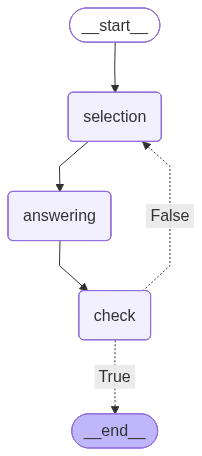

In [28]:
from IPython.display import Image
Image(compiled.get_graph().draw_mermaid_png())
